# Problem Set 1: Exploratory Data Analysis & Visualization
**Datasets:** *Little Women* by Louisa May Alcott (parsed from raw text provided by *Project Gutenberg*), *Mario Kart Item Probability* by Nintendo

**Overview:**
In this problem set, you will perform exploratory data analysis and visusalization on literary characters using either **Python** or **R**. 

**Instructions:**
* To complete this problem set in Python, use `pandas`, `numpy`, `matplotlib`, `seaborn` libraries. 
* For each problem, write your code in the provided code cell and answer any interpretation questions in a markdown cell below it.
* AI assistance is permitted, provided that all code is understood and verified before submission. Consulting the relevant documentation yourself is recommended. 
* **Submission**: Complete in jupyter notebook and submit the exported .html or .pdf with your code outputs to Canvas. 

### Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Little Women dataset for Problems 1-3
url_little_women = 'https://raw.githubusercontent.com/oxy-class/comp395-ds-fall26/main/pset1/data/little_women_chapters.csv'

little_women = pd.read_csv(url_little_women)

# 2. Generate the Mario Kart Item Probability dataset for Problem 4
mk_data = {
    'Position': ['1st Place', '1st Place', '1st Place', '1st Place', '1st Place',
                 '6th Place', '6th Place', '6th Place', '6th Place', '6th Place',
                 '12th Place', '12th Place', '12th Place', '12th Place', '12th Place'],
    'Item': ['Banana', 'Green Shell', 'Mushroom', 'Blue Shell', 'Bullet Bill'] * 3,
    'Probability': [
        0.45, 0.30, 0.05, 0.00, 0.00,  # 1st Place probabilities
        0.05, 0.15, 0.40, 0.05, 0.00,  # 6th Place probabilities
        0.00, 0.00, 0.10, 0.15, 0.45   # 12th Place probabilities
    ]
}
mario_kart_df = pd.DataFrame(mk_data)

print(f"Little Women dataset loaded! Shape: {little_women.shape}")
print(f"Mario Kart dataset loaded! Shape: {mario_kart_df.shape}")

Little Women dataset loaded! Shape: (47, 3)
Mario Kart dataset loaded! Shape: (15, 3)


#### Problem 1: Counting *Little Women* Characters (5 points)
**Description:** Let's start with the dataframe `little_women`. *Little Women* is a coming-of-age novel of four sisters growing up during the American Civil War in New England. Calculate the total number of times each character (Jo, Meg, Beth, Amy, and Laurie) is mentioned across all chapters of the book. Hint: (1) use pandas' string operations (e.g., `str.count()`). (2) Consider potential noise from your string search, use `\b` in regular expression to delineat your word boundaries (https://www.regular-expressions.info/wordboundaries.html).

*Question:* Who is the most frequently mentioned character, and who is the least?

**Expected Output:** A printed summary displaying the characters and their total aggregate mention counts.

In [3]:
little_women

,chapter,title,text
0,1,CHAPTER ONE - PLAYING PILGRIMS,"""Christmas won't be Christmas without any pres..."
1,2,CHAPTER TWO - A MERRY CHRISTMAS,Jo was the first to wake in the gray dawn of C...
2,3,CHAPTER THREE - THE LAURENCE BOY,"""Jo! Jo! Where are you?"" cried Meg at the fo..."
3,4,CHAPTER FOUR - BURDENS,"""Oh, dear, how hard it does seem to take up ou..."
4,5,CHAPTER FIVE - BEING NEIGHBORLY,"""What in the world are you going to do now, Jo..."
5,6,CHAPTER SIX - BETH FINDS THE PALACE BEAUTIFUL,"The big house did prove a Palace Beautiful, th..."
6,7,CHAPTER SEVEN - AMY'S VALLEY OF HUMILIATION,"""That boy is a perfect cyclops, isn't he?"" sai..."
7,8,CHAPTER EIGHT - JO MEETS APOLLYON,"""Girls, where are you going?"" asked Amy, comin..."
8,9,CHAPTER NINE - MEG GOES TO VANITY FAIR,"""I do think it was the most fortunate thing in..."
9,10,CHAPTER TEN - THE P.C. AND P.O.,"As spring came on, a new set of amusements bec..."


In [ ]:
text_list = pd.Series(little_women['text'].to_list())

print("Jo Total:", text_list.str.count("Jo").sum())
print("Jo Total (w/o noise):", text_list.str.count(r"\bJo\b").sum())

print("Meg Total:", text_list.str.count("Meg").sum())
print("Meg Total (w/o noise):", text_list.str.count(r"\bMeg\b").sum())

print("Beth Total:", text_list.str.count("Beth").sum())
print("Beth Total (w/o noise):", text_list.str.count(r"\bBeth\b").sum())

print("Amy Total:", text_list.str.count("Amy").sum())
print("Amy Total (w/o noise):", text_list.str.count(r"\bAmy\b").sum())

print("Laurie Total:", text_list.str.count("Laurie").sum())
print("Laurie Total (w/o noise):", text_list.str.count(r"\bLaurie\b").sum())

Jo Total: 1543
Jo Total (w/o noise): 1355
Meg Total: 685
Meg Total (w/o noise): 683
Beth Total: 465
Beth Total (w/o noise): 459
Amy Total: 645
Amy Total (w/o noise): 645
Laurie Total: 596
Laurie Total (w/o noise): 596
We can see that Jo is the character that is mentioned the most in Little Women, and Beth is the least mentioned.


We can see that Jo is the character that is mentioned the most in Little Women, and Beth is the least mentioned.

#### Problem 2a: Character Trajectories with Line Plots (5 points)
**Description:** Let's visualize how the focus on different characters shifts as the story progresses. Create a line plot tracking the number of mentions per chapter for **Jo** and **Amy**. The x-axis should represent the Chapter number (using the row index), and the y-axis should represent the number of mentions.

**Expected Output:** A line chart containing two distinct lines. The plot must include a title, labeled axes (X = Chapter, Y = Mentions), and a legend distinguishing the two characters.

<Axes: title={'center': 'Number of Times Jo and Amy mentioned in Little Women'}, xlabel='Chapter', ylabel='Mentions'>

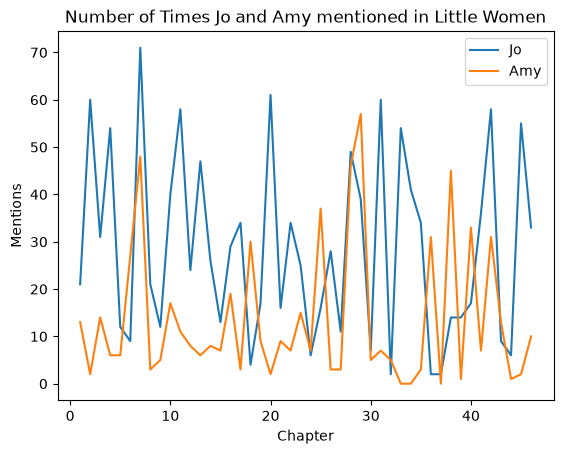

In [18]:
jo_amy = pd.DataFrame(
    {
        "Jo": text_list.str.count(r"\bJo\b"),
        "Amy":text_list.str.count(r"\bAmy\b"),
    },
        index = little_women['chapter'],    
    )
lines = jo_amy.plot.line()
lines.set_ylabel("Mentions")
lines.set_xlabel("Chapter")
lines.set_title('Number of Times Jo and Amy mentioned in Little Women')
lines

#### Problem 2b: Character Trajectories in Cumulative Mentions (5 points)

Now let's calculate and visualize the *cumulative* number of mentions for Jo and Amy across chapters. This will show how their total mentions grow throughout the book. `pandas` and `numpy` both have `cumsum()` methods. 

Text(0.5, 1.0, 'Times Jo and Amy mentioned in Little Women (Cumulative)')

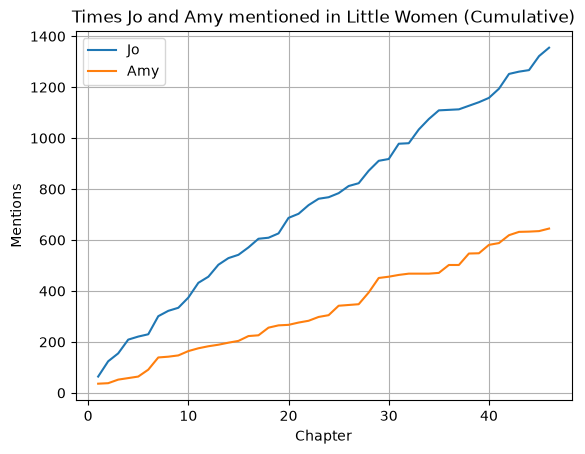

In [16]:
cumsum_jo_amy = pd.DataFrame(
    {
        "Jo": text_list.str.count(r"\bJo\b").cumsum(),
        "Amy":text_list.str.count(r"\bAmy\b").cumsum(),
    },
        index = little_women['chapter'], 
)

lines = cumsum_jo_amy.plot.line(grid = True)
lines.set_ylabel('Mentions')
lines.set_xlabel('Chapter')
lines.set_title('Times Jo and Amy mentioned in Little Women (Cumulative)')

#### Problem 3: Distribution of Mentions (5 points)
**Description:** Plot a histogram showing the distribution of chapter mentions for **Laurie**. Experiment with the number of bins (try between 10 and 15) so the shape of the distribution is clear.

*Question:* Is his distribution roughly symmetric, left-skewed, or right-skewed? What does this tell you about his usual presence in a given chapter?

**Expected Output:** A single histogram displaying the frequency of Laurie's mention counts. The plot must include appropriate titles and axis labels (X = Number of Mentions, Y = Frequency).

Text(0.5, 1.0, 'Laurie Mentions in Little Women')

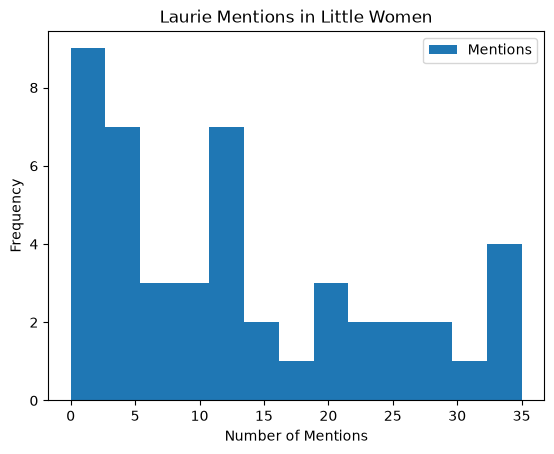

In [ ]:
Laurie = pd.DataFrame(
    {
        'Mentions': text_list.str.count(r"\bLaurie\b")
    },
    index = little_women['chapter'],
)
plot = Laurie.plot.hist(bins = 13)
plot.set_xlabel('Number of Mentions')
plot.set_title('Laurie Mentions in Little Women')

We can see that Laurie's mentions in the histogram is right-skewed, which tells us that he is more important(or more prevalent) in the earlier chapters of the book, while not as prevalent in the later part of the book.

#### Problem 4: The Catch-Up Mechanic with Grouped Bar Chart (5 points)
*Disclaimer:* Your TA is a sucker for Mario Kart so you may get multiple problems relating to that this semester.

**Description:** Look at the `mario_kart_df` dataset we loaded earlier. This dataset contains the probability of pulling certain items from an item box based on your current race position (1st, 6th, or 12th place).

Create a **grouped bar chart** to visualize this data.
1. The x-axis should represent the `Item`.
2. The y-axis should represent the `Probability`.
3. Group or color the bars by `Position` so we can compare the item probabilities side-by-side. *(Hint: `sns.barplot()` with the `hue` parameter makes this easy).*
4. Consider your coloring choices for best visualization effects.

*Question:* Based on your visualization, which item acts as the ultimate "catch-up" mechanism for players in 12th place, and why do you think Nintendo programmed the probabilities this way?

**Expected Output:** A single bar chart with grouped bars, including a legend, a title, and properly labeled axes.

In [26]:
mario_kart_df

,Position,Item,Probability
0,1st Place,Banana,0.45
1,1st Place,Green Shell,0.30
2,1st Place,Mushroom,0.05
3,1st Place,Blue Shell,0.00
4,1st Place,Bullet Bill,0.00
5,6th Place,Banana,0.05
6,6th Place,Green Shell,0.15
7,6th Place,Mushroom,0.40
8,6th Place,Blue Shell,0.05
9,6th Place,Bullet Bill,0.00


<Axes: xlabel='Item', ylabel='Probability'>

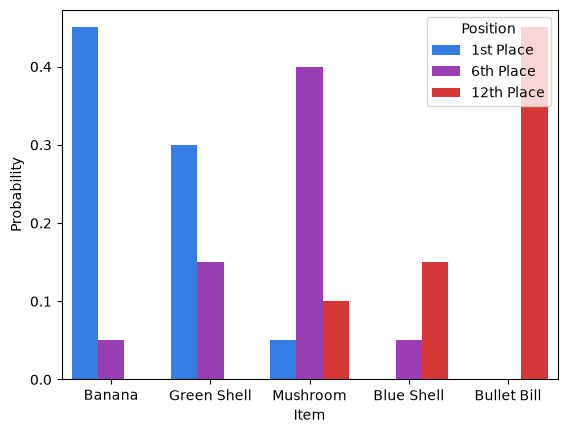

In [31]:
colors = {'1st Place':  "#1878ff",   
    '6th Place':  "#a52bc7",   
    '12th Place': "#f01e1e",  
    }
sns.barplot(data=mario_kart_df, x='Item', y='Probability', hue='Position', palette=colors)

You are done with Problem Set 1! 